# Overview DATA

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
data=pd.read_csv("train.csv")
data.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [18]:
print(data.shape)

(2781, 16)


In [19]:
data.drop("Id",axis=1,inplace=True)
data.head()

,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [20]:
data.drop("School",axis=1,inplace=True)

In [21]:
data.drop("Year",axis=1,inplace=True)

In [22]:
print(len(list(data["Position_Type"].unique())))
print(len(list(data["Player_Type"].unique())))

7
3


In [23]:
data.shape

(2781, 13)

In [24]:
data["Drafted"].value_counts()

Drafted
1.0    1803
0.0     978
Name: count, dtype: int64

In [25]:
data.head()

,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,21.0,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,24.0,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,21.0,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,21.0,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,21.0,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [26]:
len(list(data["Position"].unique()))

20

In [27]:
# age is very important so lets see the age of 1 and zero 
# BMI is very important too
# ratio btw Bench_Press / weight ( relative stregth ) src=GYM
# how std is far from the std of the sprint, vertical jump 

In [28]:
data.isna().sum()

Age                 435
Height                0
Weight                0
Sprint_40yd         145
Vertical_Jump       554
Bench_Press_Reps    721
Broad_Jump          581
Agility_3cone       970
Shuttle             912
Player_Type           0
Position_Type         0
Position              0
Drafted               0
dtype: int64

# High Corr 

In [29]:
num_cols=data.select_dtypes(include="number").columns

corr_data=data.loc[:,num_cols]

corr_matrix=corr_data.corr()


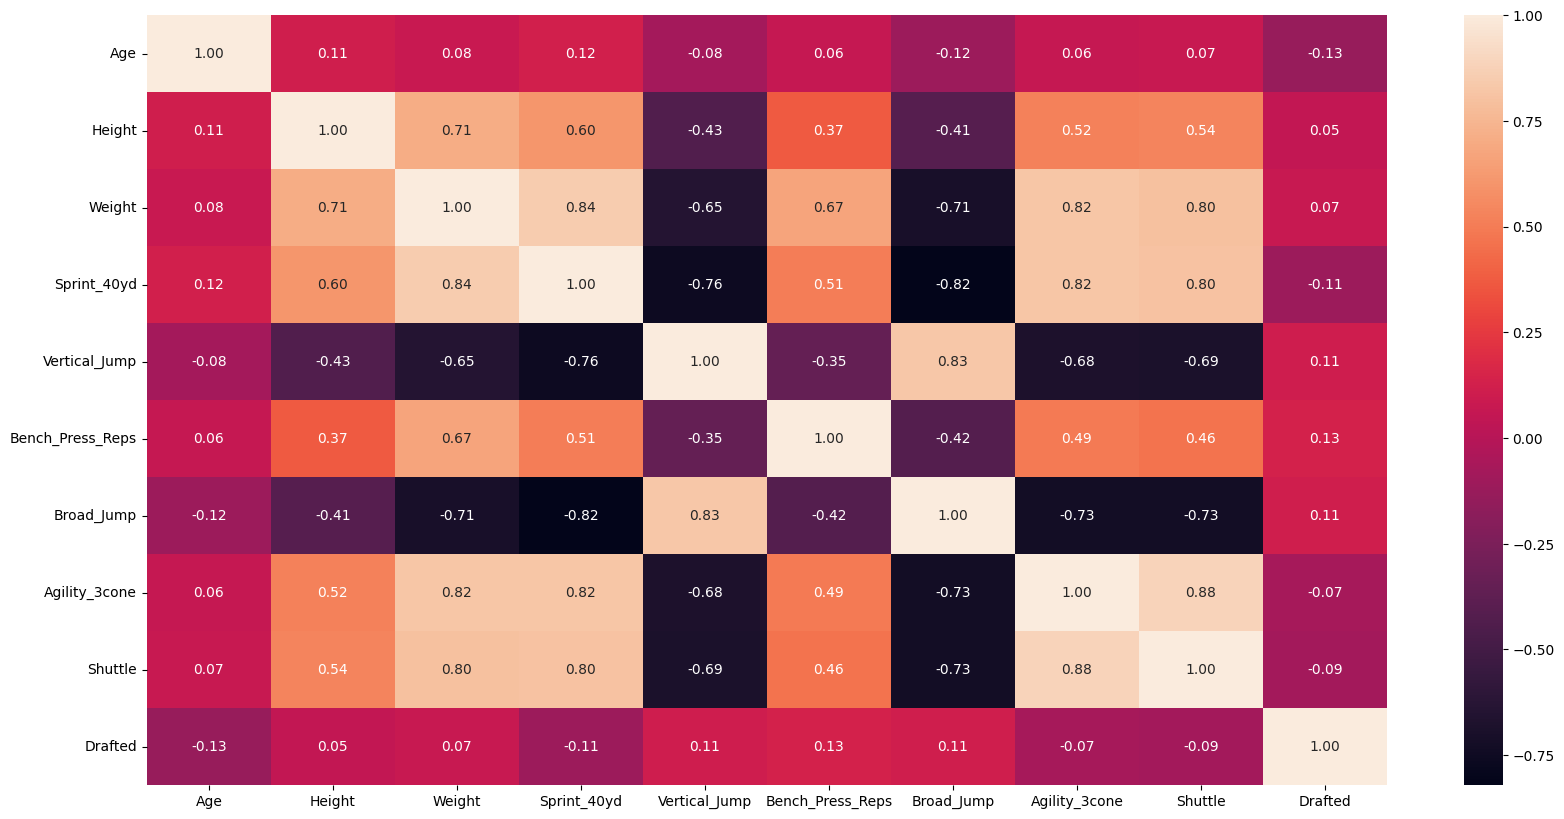

In [30]:
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix,fmt=".2f",annot=True,)
plt.show()

In [31]:
type(corr_matrix)

pandas.core.frame.DataFrame

In [32]:
abs_corr_matrix=corr_matrix.abs()
ones_matrix=np.ones(shape=abs_corr_matrix.shape).astype(bool)
lower_trig=np.tril(ones_matrix,k=-1)
lower_corr=abs_corr_matrix.where(lower_trig)
lower_corr=lower_corr.unstack()
lower_corr=lower_corr.dropna()

In [33]:
lower_corr

Age               Height              0.111377
                  Weight              0.082392
                  Sprint_40yd         0.122848
                  Vertical_Jump       0.078574
                  Bench_Press_Reps    0.064357
                  Broad_Jump          0.115926
                  Agility_3cone       0.061936
                  Shuttle             0.068932
                  Drafted             0.133055
Height            Weight              0.705727
                  Sprint_40yd         0.603278
                  Vertical_Jump       0.430196
                  Bench_Press_Reps    0.367146
                  Broad_Jump          0.408969
                  Agility_3cone       0.517658
                  Shuttle             0.535568
                  Drafted             0.046875
Weight            Sprint_40yd         0.844383
                  Vertical_Jump       0.647688
                  Bench_Press_Reps    0.671284
                  Broad_Jump          0.707087
             

In [34]:
sort_high_corr=lower_corr.sort_values(ascending=False)
sort_high_corr=sort_high_corr.reset_index()
sort_high_corr.columns=["first","second","corr"]
sort_high_corr
# Shuttle , Agility_3cone high accuracy with weight and they have many nan values so we can delete them and depend on the weight

,first,second,corr
0,Agility_3cone,Shuttle,0.879571
1,Weight,Sprint_40yd,0.844383
2,Vertical_Jump,Broad_Jump,0.828637
3,Sprint_40yd,Broad_Jump,0.820895
4,Weight,Agility_3cone,0.817706
5,Sprint_40yd,Agility_3cone,0.816042
6,Sprint_40yd,Shuttle,0.801723
7,Weight,Shuttle,0.796042
8,Sprint_40yd,Vertical_Jump,0.757027
9,Broad_Jump,Shuttle,0.729444


In [35]:
data_no_corr=data.drop(["Shuttle" , "Agility_3cone"],axis=1)
data_no_corr.shape

(2781, 11)

# Model for know the basic importance feature not the FINAL model

In [36]:
data_no_corr.isna().sum()

Age                 435
Height                0
Weight                0
Sprint_40yd         145
Vertical_Jump       554
Bench_Press_Reps    721
Broad_Jump          581
Player_Type           0
Position_Type         0
Position              0
Drafted               0
dtype: int64

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder
from sklearn.impute import SimpleImputer

In [38]:
data_x_first=data_no_corr.drop("Drafted",axis=1)
data_y_first=data_no_corr["Drafted"]

In [39]:
num_cols=data_x_first.select_dtypes("number").columns
cat_cols=data_x_first.select_dtypes("object").columns
print(num_cols)
print(cat_cols)

Index(['Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
       'Bench_Press_Reps', 'Broad_Jump'],
      dtype='object')
Index(['Player_Type', 'Position_Type', 'Position'], dtype='object')


In [40]:
num_pipe=Pipeline(
    steps=[
        ("nan_num",SimpleImputer(strategy="median")),
        ("standardization",StandardScaler())
    ]
)
cat_pipe=Pipeline(
    steps=[
        ("nan_cat",SimpleImputer(strategy="most_frequent")),
        ("encoding",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
    ],
)

In [41]:
col_transform=ColumnTransformer(
    transformers=[
        ("num_transform",num_pipe,num_cols),
        ("cat_transform",cat_pipe,cat_cols)
    ],verbose_feature_names_out=False
)

In [42]:
num_cols

Index(['Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
       'Bench_Press_Reps', 'Broad_Jump'],
      dtype='object')

In [43]:
from sklearn.ensemble import RandomForestClassifier

data_pre=col_transform.fit_transform(data_x_first)

In [44]:
df_data_pre=pd.DataFrame(data_pre,columns=col_transform.get_feature_names_out())
df_data_pre.head()

,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Player_Type,Position_Type,Position
0,-1.125851,0.467641,1.509980,2.156260,-2.491704,1.599565,-1.928488,1.0,5.0,10.0
1,2.260225,-0.666855,-1.103859,-1.542508,1.881513,-0.756766,1.887155,1.0,0.0,19.0
2,-1.125851,-0.288689,-0.813432,-0.857551,0.821339,-1.844303,0.814006,1.0,0.0,19.0
3,-1.125851,0.845807,1.934450,1.128824,-0.768921,3.412127,-1.809249,0.0,2.0,4.0
4,-1.125851,0.089476,-0.858113,-0.412329,-0.503878,-0.031741,-0.497622,1.0,0.0,19.0


In [45]:
rf_model=RandomForestClassifier(n_estimators=100)

from sklearn.model_selection import cross_val_score

In [46]:
scores=cross_val_score(rf_model,df_data_pre,data_y_first,cv=3)

In [47]:
scores

array([0.69687163, 0.69471413, 0.70981661])

In [48]:
rf_model.fit(df_data_pre,data_y_first)
im_features=rf_model.feature_importances_

In [49]:
df_im_feature=pd.DataFrame({
    "Names":data_x_first.columns,
    "Score":im_features
}).sort_values(by="Score",ascending=False)


In [50]:
df_im_feature

,Names,Score
3,Sprint_40yd,0.189078
2,Weight,0.178613
6,Broad_Jump,0.119917
4,Vertical_Jump,0.115076
5,Bench_Press_Reps,0.109931
1,Height,0.095267
0,Age,0.089201
9,Position,0.054643
7,Player_Type,0.026239
8,Position_Type,0.022035


In [51]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(df_data_pre,data_y_first)

xgb_importances = xgb_model.feature_importances_
feature_names=data_x_first.columns
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False)

booster = xgb_model.get_booster()
booster.feature_names = list(feature_names)
gain_scores = booster.get_score(importance_type='gain')

xgb_gain_df = pd.DataFrame({
    'Feature': list(gain_scores.keys()),
    'Gain Score': list(gain_scores.values())
}).sort_values(by='Gain Score', ascending=False)

In [52]:
scores=cross_val_score(xgb_model,df_data_pre,data_y_first,cv=3)
scores

array([0.66990291, 0.6763754 , 0.68392665])

In [53]:
xgb_importance_df

,Feature,Importance
0,Age,0.234397
7,Player_Type,0.151063
8,Position_Type,0.108110
3,Sprint_40yd,0.096391
2,Weight,0.078274
5,Bench_Press_Reps,0.069418
6,Broad_Jump,0.068673
9,Position,0.066754
1,Height,0.064971
4,Vertical_Jump,0.061948


In [54]:
xgb_gain_df

,Feature,Gain Score
0,Age,4.795270
7,Player_Type,3.090426
8,Position_Type,2.211709
3,Sprint_40yd,1.971950
2,Weight,1.601323
5,Bench_Press_Reps,1.420147
6,Broad_Jump,1.404907
9,Position,1.365637
1,Height,1.329175
4,Vertical_Jump,1.267317


# Try on all the data

In [55]:
data_x=data.drop("Drafted",axis=1)
data_y=data["Drafted"]

In [56]:
num_cols=data_x.select_dtypes(include="number").columns
num_cols=data_x.select_dtypes(include="object").columns


In [57]:
data_x=col_transform.fit_transform(data_x)

In [58]:
scores=cross_val_score(rf_model,data_x,data_y,cv=5)
scores

array([0.6929982 , 0.68165468, 0.70323741, 0.71043165, 0.70683453])

In [59]:
# Position is not important enough for the model

# Now Start Visualize

In [60]:
data_no_corr.head()

,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Player_Type,Position_Type,Position,Drafted
0,21.0,1.9050,140.160042,5.39,59.69,29.0,251.46,offense,offensive_lineman,OG,1.0
1,24.0,1.8288,87.089735,4.31,101.60,16.0,332.74,offense,backs_receivers,WR,1.0
2,21.0,1.8542,92.986436,4.51,91.44,10.0,309.88,offense,backs_receivers,WR,1.0
3,21.0,1.9304,148.778297,5.09,76.20,39.0,254.00,defense,defensive_lineman,DT,1.0
4,21.0,1.8796,92.079251,4.64,78.74,NaN,281.94,offense,backs_receivers,WR,1.0


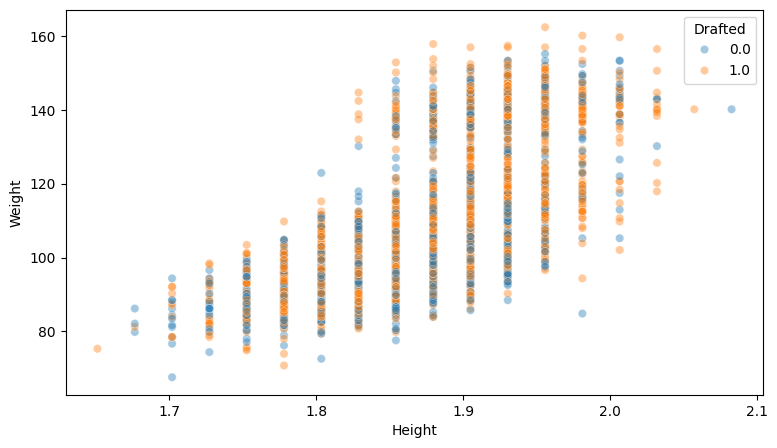

In [61]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data_no_corr,x="Height",y="Weight",hue="Drafted",alpha=0.4)
plt.show()

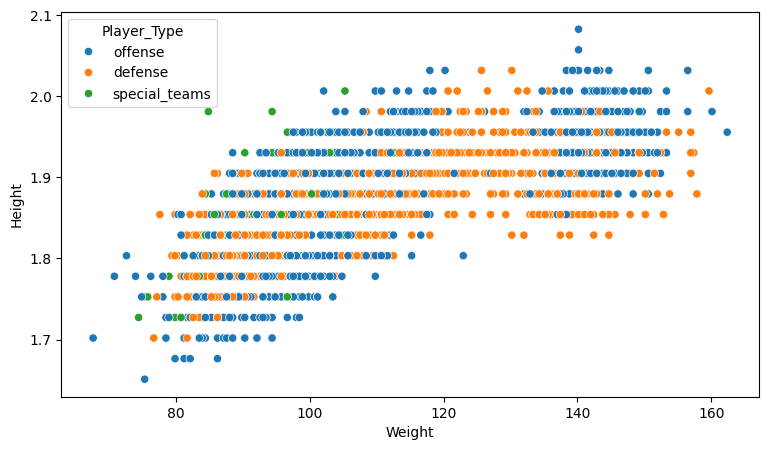

In [62]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data_no_corr,y="Height",x="Weight",hue="Player_Type")
plt.show()

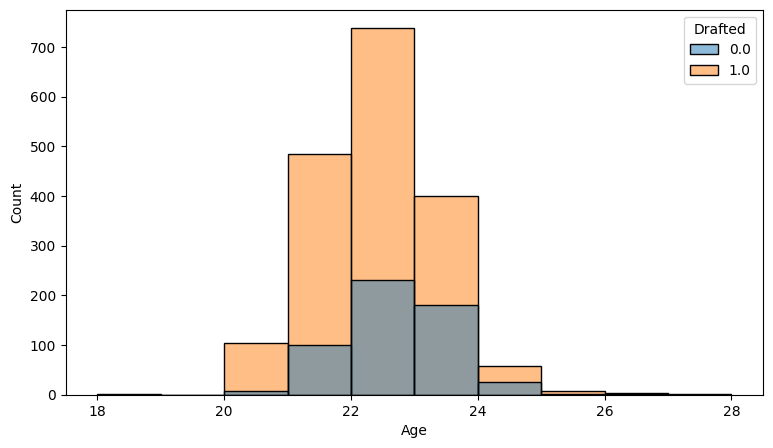

In [63]:
plt.figure(figsize=(9,5))
sns.histplot(data=data_no_corr,x="Age",hue="Drafted",bins=10)
plt.show()
# most of the Drafted from 20 to 24 and has good distribution

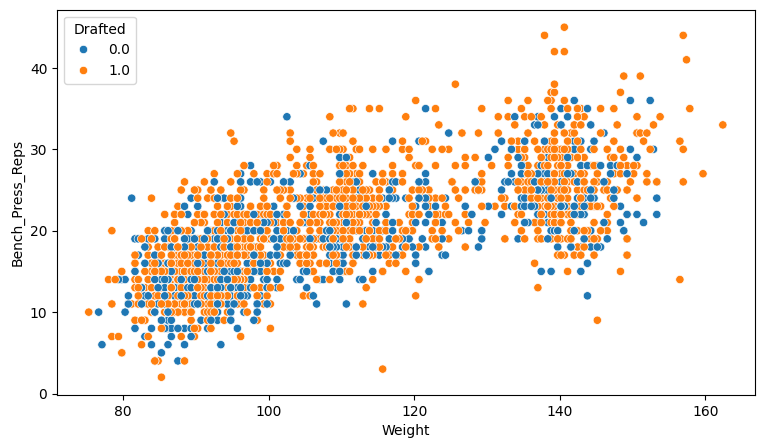

In [64]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data_no_corr,y="Bench_Press_Reps",x="Weight",hue="Drafted")
plt.show()
# as shown here there are high relation between weight and the height

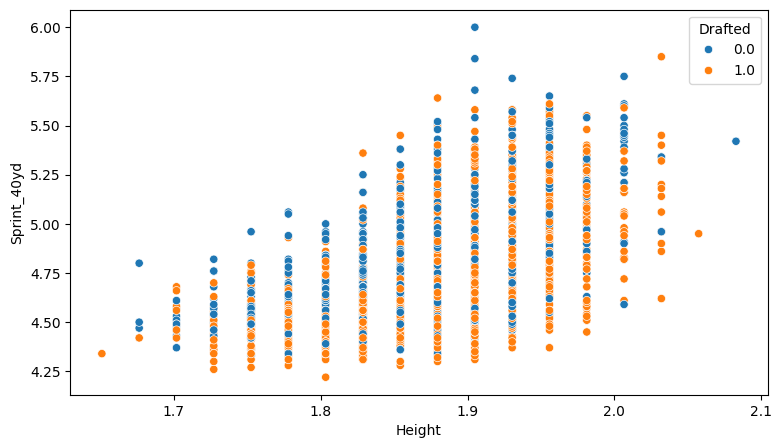

In [65]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data_no_corr,y="Sprint_40yd",x="Height",hue="Drafted")
plt.show()

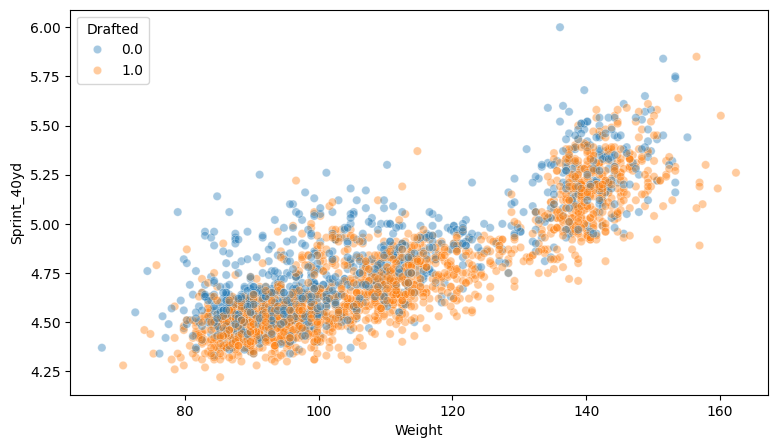

In [66]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data_no_corr,y="Sprint_40yd",x="Weight",hue="Drafted",alpha=0.4)
plt.show()

## I can't treat with height and weight alone so let's create bmi feature

In [67]:
BMI=data_no_corr["Weight"]/(data_no_corr["Height"]**2)

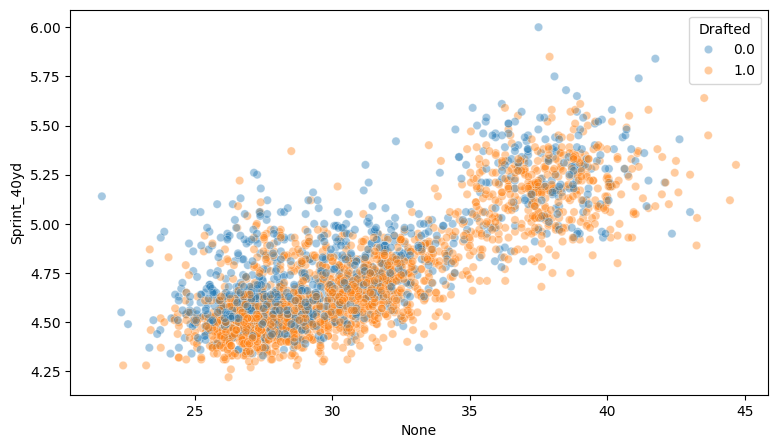

In [68]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data_no_corr,y="Sprint_40yd",x=BMI,hue="Drafted",alpha=0.4)
plt.show()
# the heighest Drafted are in the lower BMI maybe there are some positions need high weight

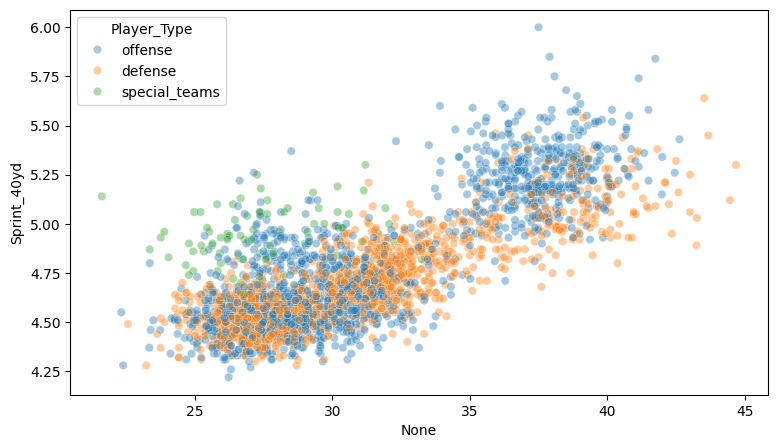

In [69]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data_no_corr,y="Sprint_40yd",x=BMI,hue="Player_Type",alpha=0.4)
plt.show()
# defense has height weight 
# special_teams should be light weight

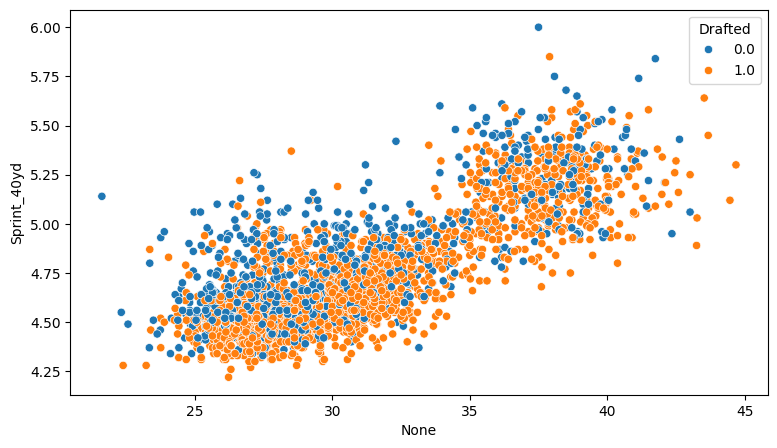

In [70]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data_no_corr,y="Sprint_40yd",x=BMI,hue="Drafted")
plt.show()

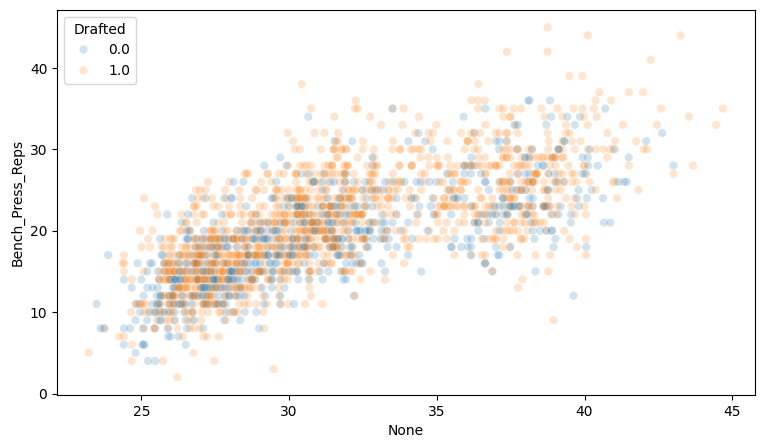

In [71]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data_no_corr,y="Bench_Press_Reps",x=BMI,hue="Drafted",alpha=0.2)
plt.show()
# we can extract they choose the most power people

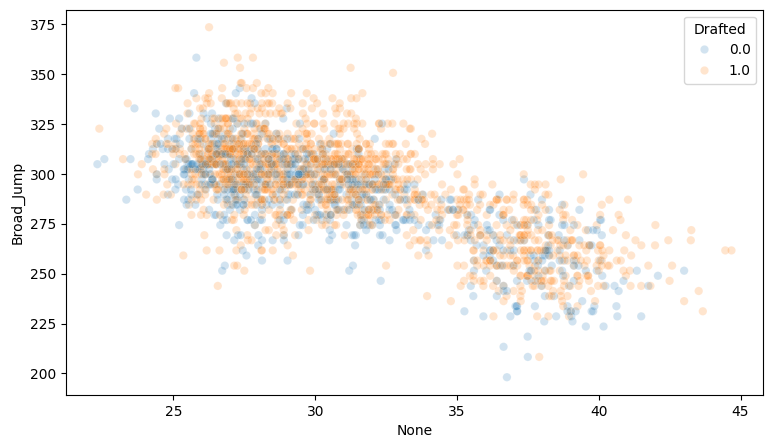

In [72]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data_no_corr,y="Broad_Jump",x=BMI,hue="Drafted",alpha=0.2)
plt.show()
# that makes sense low BMI Heigher jump
# and they drafted the people has high power too

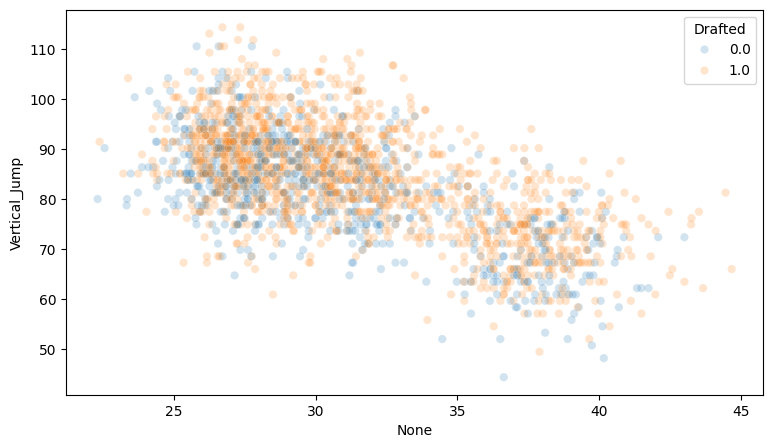

In [73]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=data_no_corr,y="Vertical_Jump",x=BMI,hue="Drafted",alpha=0.2)
plt.show()

In [74]:
num_cols=data_no_corr.select_dtypes(include='number').columns

# Let's Remove the outliers

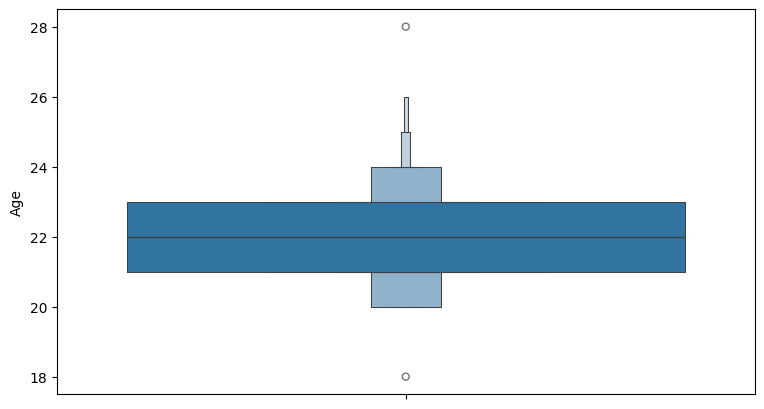

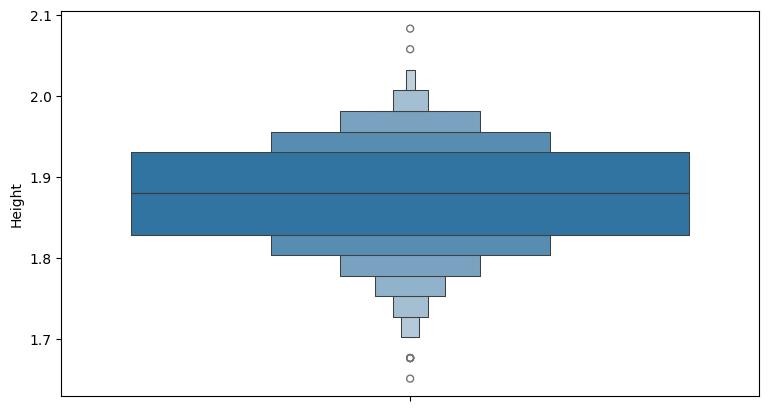

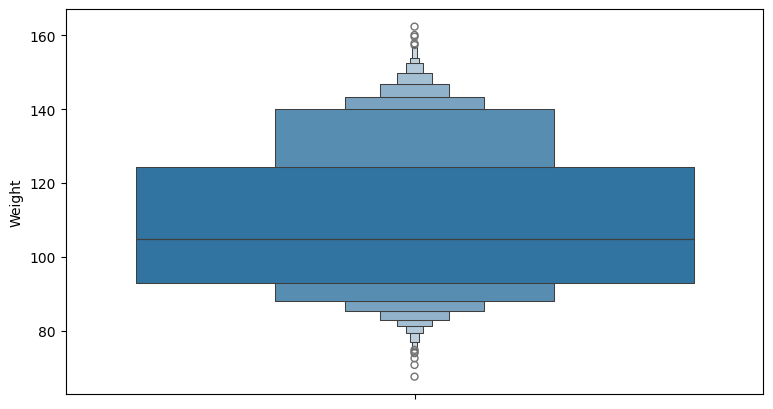

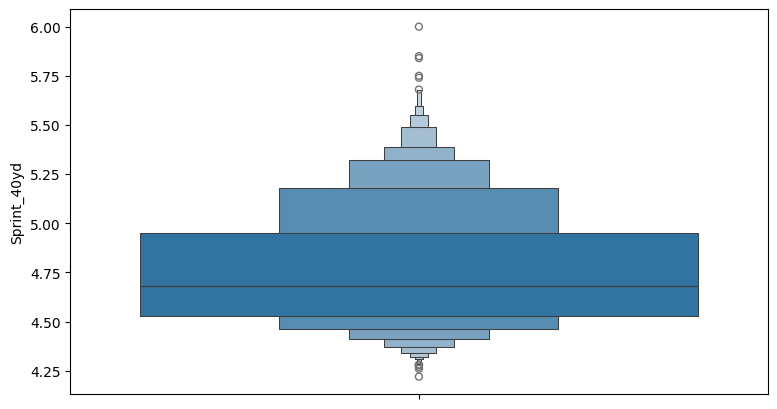

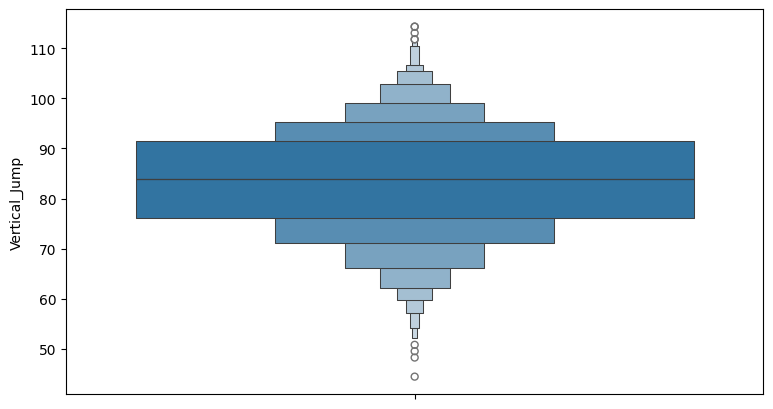

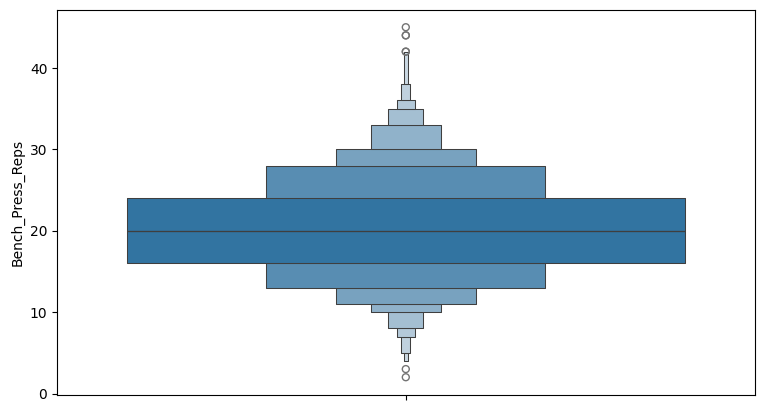

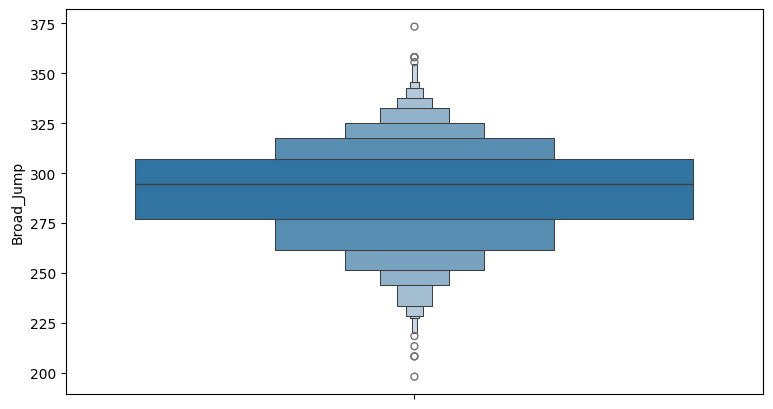

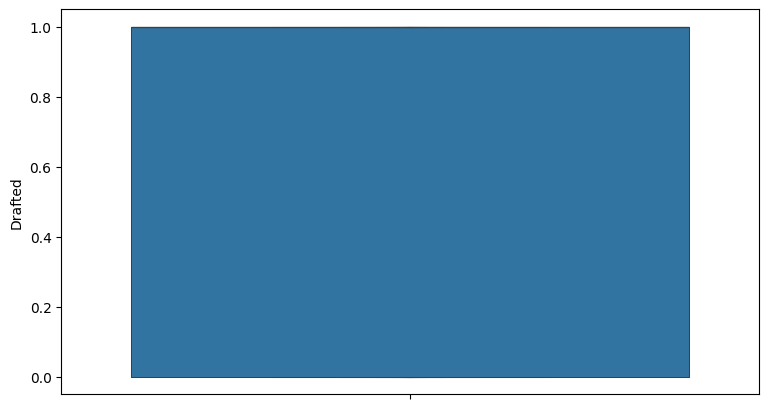

In [75]:
for x in num_cols:
    
    plt.figure(figsize=(9,5))
    sns.boxenplot(data_no_corr[x])
    plt.show()

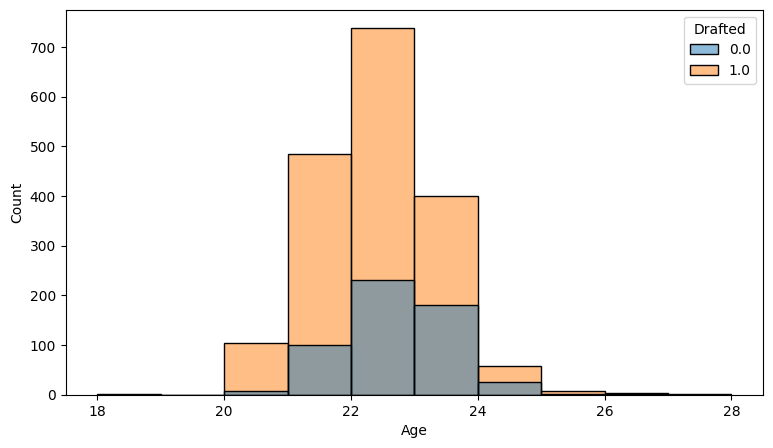

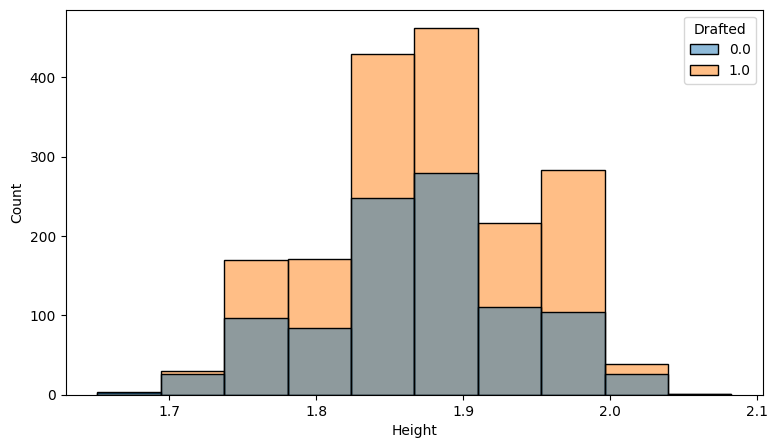

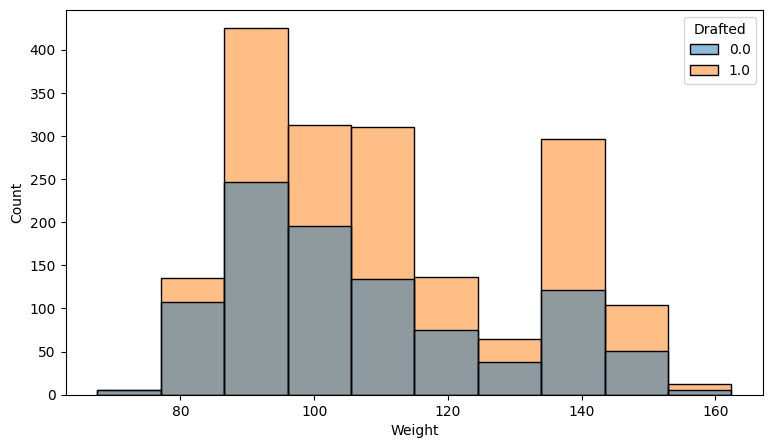

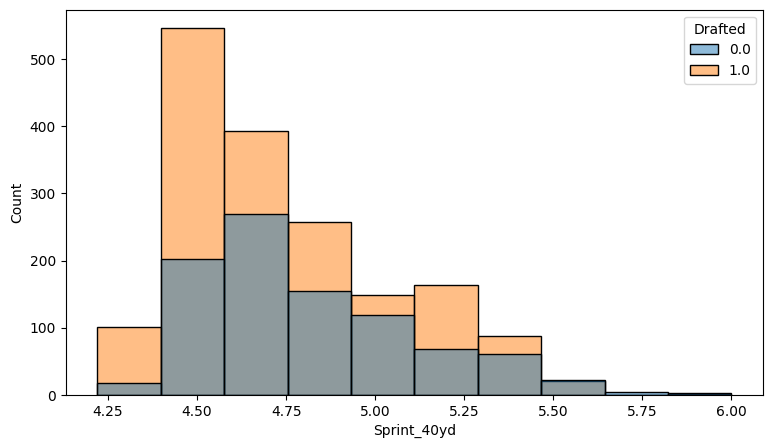

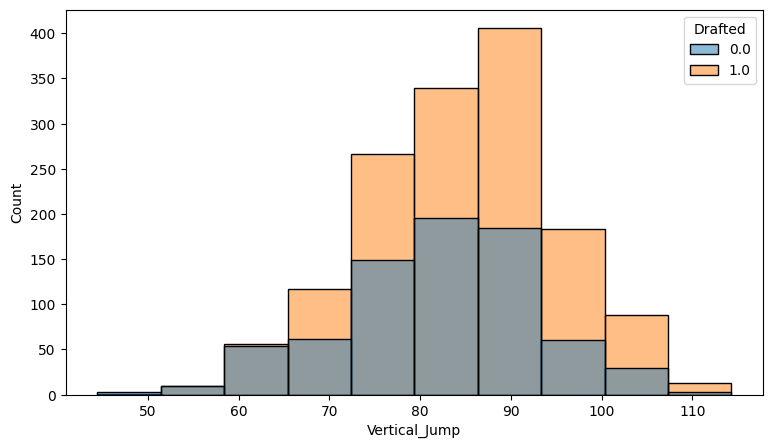

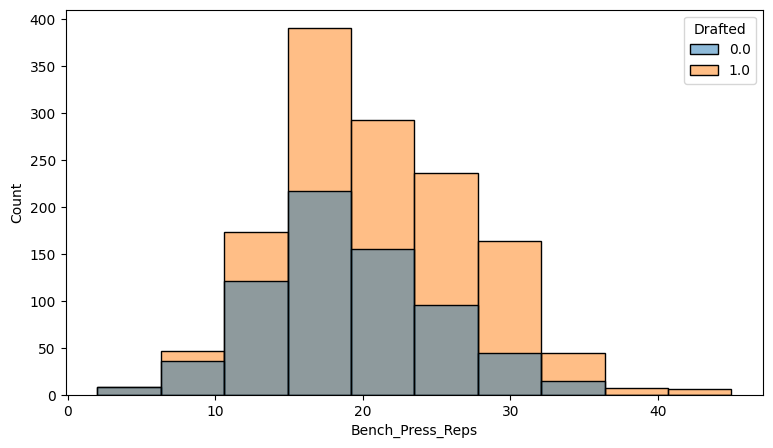

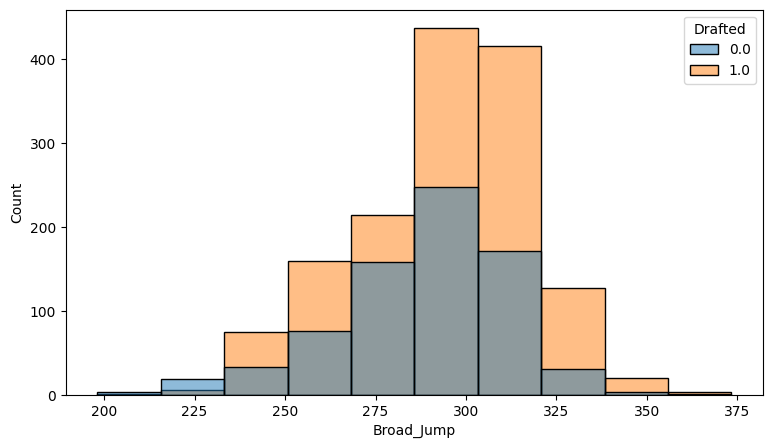

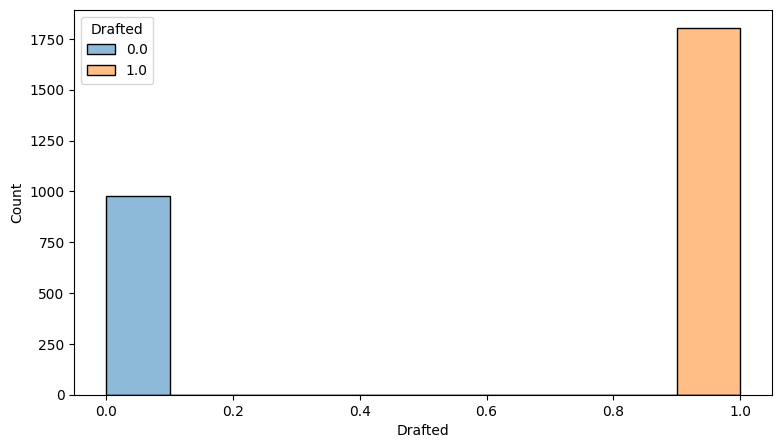

In [76]:
for x in num_cols:
    
    plt.figure(figsize=(9,5))
    sns.histplot(data=data_no_corr,x=x,bins=10,hue="Drafted")
    plt.show()

# From All  These Analysis this game depend on how much power you have so if we create columns more representive about how much power you have is enough 

# This is unbalance Data, too .

## I will try two methods to solve the problem of unbalanced 

In [77]:
class_count=data_no_corr["Drafted"].value_counts().values
class_count

array([1803,  978])

In [78]:
df_1_class=data_no_corr[data_no_corr["Drafted"]==1]
df_0_class=data_no_corr[data_no_corr["Drafted"]==0]

In [79]:
print(df_0_class.shape)
df_0_class=df_0_class.sample(class_count[0],replace=True)
print(df_0_class.shape)


(978, 11)
(1803, 11)


In [80]:
full_data_balanced_1=pd.concat([df_0_class,df_1_class],axis=0)
full_data_balanced_1.shape

(3606, 11)

In [81]:
full_data_balanced_1.head()

,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Player_Type,Position_Type,Position,Drafted
1425,NaN,1.8796,85.275366,4.52,101.60,NaN,309.88,offense,backs_receivers,WR,0.0
530,NaN,1.9050,108.862169,4.77,76.20,24.0,294.64,offense,backs_receivers,FB,0.0
690,NaN,1.9050,110.676538,4.89,100.33,21.0,304.80,defense,line_backer,ILB,0.0
1311,NaN,1.8288,91.172066,4.51,100.33,13.0,325.12,defense,defensive_back,CB,0.0
2222,22.0,1.9558,113.851685,4.75,73.66,NaN,302.26,offense,backs_receivers,QB,0.0


# Second_Method

In [85]:
from imblearn.over_sampling import SMOTE

In [86]:
x_data_un=data_no_corr.drop("Drafted",axis=1)
y_data_un=data_no_corr["Drafted"]

In [87]:
x_data_un.drop("Position",inplace=True,axis=1)

In [88]:
num_cols=x_data_un.select_dtypes(include="number").columns
cat_cols=x_data_un.select_dtypes(include="object").columns

In [89]:
cat_pip=Pipeline(
    steps=[
        ("nan_value",SimpleImputer(strategy="most_frequent")),
        ("encoding",OneHotEncoder(sparse_output=False,handle_unknown="ignore"))
    ]
)

num_pip=Pipeline(
    steps=[
        ("handle_nan",SimpleImputer(strategy="mean"))
    ]
)

col_cat_num=ColumnTransformer(
    transformers=[
        ("pre_cat",cat_pip,cat_cols),
        ("pre_num",num_pip,num_cols)
    ],verbose_feature_names_out=False,remainder="passthrough"
)

In [90]:
x_data_un=col_cat_num.fit_transform(x_data_un)
x_data_un=pd.DataFrame(x_data_un,columns=col_cat_num.get_feature_names_out())

In [91]:
smote=SMOTE(sampling_strategy="minority")
x_balanced , y_balanced=smote.fit_resample(x_data_un,y_data_un)
y_balanced.value_counts()

Drafted
1.0    1803
0.0    1803
Name: count, dtype: int64

# lat's Start Create Our Transformers

In [92]:
from sklearn.base import BaseEstimator, TransformerMixin

In [93]:
class My_Transform(BaseEstimator,TransformerMixin):
    
    def __init__(self,Press_Rate=True,BMI=True,Speed_Ratio=True,Jump_Power=True,Power=True):
        self.Press_Rate=Press_Rate
        self.BMI=BMI
        self.Speed_Ratio=Speed_Ratio
        self.Jump_Power=Jump_Power
        self.Power=Power
    def fit(self,X,y=None):
        return self
    
    def transform (self,X):
        X=X.copy()
        if self.BMI:
            X["BMI"]=X["Weight"]/(X["Height"]**2)
        if self.Press_Rate:
            X["Press_Rate"] = X["Bench_Press_Reps"] / X["Weight"]
        if self.Speed_Ratio:
            
            X["Speed_Ratio"]=X["Weight"]/X["Sprint_40yd"]
            
        if self.Jump_Power:
            
            X["Jump_Power"]= X["Vertical_Jump"] * X["Broad_Jump"]
        
        if self.Power:
            
            X["Power"] = X["Sprint_40yd"] * X["Vertical_Jump"] * X["Broad_Jump"]
        
        return X
        
        

# Let's Choose the best model , data , additional features 

In [94]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [95]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [96]:
data_no_corr_x=data_no_corr.drop(["Drafted","Position"],axis=1)
data_no_corr_y=data_no_corr["Drafted"]

In [97]:
from sklearn.compose import make_column_selector

In [98]:
num_pipe=Pipeline(
    steps=[
        ("nan_values",SimpleImputer(strategy="mean")),
        ("normalization",StandardScaler())
    ]
)
cat_pipe=Pipeline(
    steps=[
        ("nan_value_c",SimpleImputer(strategy="most_frequent")),
        ("encoding",OneHotEncoder(sparse_output=False,handle_unknown="ignore"))
    ]
)

full_transform=ColumnTransformer(
    transformers=[
        ("num_pre",num_pipe,make_column_selector(dtype_include="number")),
        ("cat_pre",cat_pipe,make_column_selector(dtype_include="object"))
    ]
)

In [99]:
full_pipe=Pipeline(
    steps=[
        ("New_Feature",My_Transform()),
        ("Col_Transformer",full_transform),
        ("model",RandomForestClassifier(random_state=42))
    ]
)

# Let's Try To fine tuning it

In [100]:
from scipy.stats import randint

In [101]:

param_distributions = {
    "New_Feature__BMI": [True, False],
    "New_Feature__Press_Rate": [True, False],
    "New_Feature__Speed_Ratio": [True, False],
    "New_Feature__Jump_Power": [True, False],
    "New_Feature__Power": [True, False],
    "model__n_estimators": randint(50, 500),
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": randint(2, 11),
    "model__min_samples_leaf": randint(1, 11),
    "model__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=full_pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=1
)

random_search.fit(data_no_corr_x, data_no_corr_y)

print("Best Score (AUC-ROC):", random_search.best_score_)
print("Best Parameters:", random_search.best_params_)

Best Score (AUC-ROC): 0.8251138401237332
Best Parameters: {'New_Feature__BMI': False, 'New_Feature__Jump_Power': False, 'New_Feature__Power': False, 'New_Feature__Press_Rate': False, 'New_Feature__Speed_Ratio': True, 'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__min_samples_split': 7, 'model__n_estimators': 363}


# Second Model

In [102]:
full_pipe_2=Pipeline(
    steps=[
        ("New_Feature",My_Transform()),
        ("Col_Transformer",full_transform),
        ("model",XGBClassifier(random_state=42))
    ]
)

In [103]:
from scipy.stats import uniform


param_distributions = {
    "New_Feature__BMI": [True, False],
    "New_Feature__Press_Rate": [True, False],
    "New_Feature__Speed_Ratio": [True, False],
    "New_Feature__Jump_Power": [True, False],
    "New_Feature__Power": [True, False],
    "model__n_estimators": randint(50, 500),
    "model__max_depth": [3, 5, 7, 10, 15],
    "model__learning_rate": uniform(0.01, 0.3),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__gamma": uniform(0, 5)
}

xgb_search = RandomizedSearchCV(
    estimator=full_pipe_2,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=1
)

xgb_search.fit(data_no_corr_x, data_no_corr_y)

print("Best Score (AUC-ROC):", xgb_search.best_score_)
print("Best Parameters:", xgb_search.best_params_)

Best Score (AUC-ROC): 0.8299983463091891
Best Parameters: {'New_Feature__BMI': False, 'New_Feature__Jump_Power': False, 'New_Feature__Power': True, 'New_Feature__Press_Rate': False, 'New_Feature__Speed_Ratio': True, 'model__colsample_bytree': np.float64(0.7164916560792167), 'model__gamma': np.float64(3.0592644736118975), 'model__learning_rate': np.float64(0.05184815819561255), 'model__max_depth': 10, 'model__n_estimators': 237, 'model__subsample': np.float64(0.7465447373174767)}


# Third Model

In [104]:
full_data_balanced_x=full_data_balanced_1.drop(["Drafted","Position"],axis=1)
full_data_balanced_y=full_data_balanced_1["Drafted"]

In [105]:
param_distributions = {
    "New_Feature__BMI": [True, False],
    "New_Feature__Press_Rate": [True, False],
    "New_Feature__Speed_Ratio": [True, False],
    "New_Feature__Jump_Power": [True, False],
    "New_Feature__Power": [True, False],
    "model__n_estimators": randint(50, 500),
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": randint(2, 11),
    "model__min_samples_leaf": randint(1, 11),
    "model__max_features": ["sqrt", "log2", None]
}

random_search_2 = RandomizedSearchCV(
    estimator=full_pipe,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=1
)

random_search_2.fit(full_data_balanced_x, full_data_balanced_y)

print("Best Score (AUC-ROC):", random_search_2.best_score_)
print("Best Parameters:", random_search_2.best_params_)

Best Score (AUC-ROC): 0.9493029007860079
Best Parameters: {'New_Feature__BMI': True, 'New_Feature__Jump_Power': False, 'New_Feature__Power': False, 'New_Feature__Press_Rate': False, 'New_Feature__Speed_Ratio': False, 'model__max_depth': 40, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 175}


# Fourth Model

In [106]:
param_distributions = {
    "New_Feature__BMI": [True, False],
    "New_Feature__Press_Rate": [True, False],
    "New_Feature__Speed_Ratio": [True, False],
    "New_Feature__Jump_Power": [True, False],
    "New_Feature__Power": [True, False],
    "model__n_estimators": randint(50, 500),
    "model__max_depth": [3, 5, 7, 10, 15],
    "model__learning_rate": uniform(0.01, 0.3),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__gamma": uniform(0, 5)
}

xgb_search_2 = RandomizedSearchCV(
    estimator=full_pipe_2,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=1
)

xgb_search_2.fit(full_data_balanced_x, full_data_balanced_y)

print("Best Score (AUC-ROC):", xgb_search_2.best_score_)
print("Best Parameters:", xgb_search_2.best_params_)

Best Score (AUC-ROC): 0.9456458496925114
Best Parameters: {'New_Feature__BMI': True, 'New_Feature__Jump_Power': True, 'New_Feature__Power': False, 'New_Feature__Press_Rate': True, 'New_Feature__Speed_Ratio': True, 'model__colsample_bytree': np.float64(0.7755885682822544), 'model__gamma': np.float64(0.3922819067113298), 'model__learning_rate': np.float64(0.017605223024637254), 'model__max_depth': 15, 'model__n_estimators': 367, 'model__subsample': np.float64(0.9343920482048823)}


# Fifth Model

In [107]:
from imblearn.pipeline import Pipeline as impipe

full_pipe_3=impipe(
    steps=[
        ("New_Feature",My_Transform()),
        ("Col_Transformer",full_transform),
        ("smote", SMOTE(sampling_strategy="minority", random_state=42)),
        ("model",RandomForestClassifier(random_state=42))
    ]
)

In [108]:
param_distributions = {
    "New_Feature__BMI": [True, False],
    "New_Feature__Press_Rate": [True, False],
    "New_Feature__Speed_Ratio": [True, False],
    "New_Feature__Jump_Power": [True, False],
    "New_Feature__Power": [True, False],
    "model__n_estimators": randint(50, 500),
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": randint(2, 11),
    "model__min_samples_leaf": randint(1, 11),
    "model__max_features": ["sqrt", "log2", None]
}

random_search_3 = RandomizedSearchCV(
    estimator=full_pipe_3,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=1
)

random_search_3.fit(data_no_corr_x, data_no_corr_y)

print("Best Score (AUC-ROC):", random_search_3.best_score_)
print("Best Parameters:", random_search_3.best_params_)

Best Score (AUC-ROC): 0.8182050629755417
Best Parameters: {'New_Feature__BMI': False, 'New_Feature__Jump_Power': False, 'New_Feature__Power': False, 'New_Feature__Press_Rate': False, 'New_Feature__Speed_Ratio': True, 'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__min_samples_split': 7, 'model__n_estimators': 363}


# Sixth Model

In [109]:
full_pipe_4=impipe(
    steps=[
        ("New_Feature",My_Transform()),
        
        
        
        ("Col_Transformer",full_transform),
        
        ("smote", SMOTE(sampling_strategy="minority", random_state=42)),
        
        ("model",XGBClassifier(random_state=42))
    ]
)

In [110]:
param_distributions = {
    "New_Feature__BMI": [True, False],
    "New_Feature__Press_Rate": [True, False],
    "New_Feature__Speed_Ratio": [True, False],
    "New_Feature__Jump_Power": [True, False],
    "New_Feature__Power": [True, False],
    "model__n_estimators": randint(50, 500),
    "model__max_depth": [3, 5, 7, 10, 15],
    "model__learning_rate": uniform(0.01, 0.3),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__gamma": uniform(0, 5)
}

xgb_search_3 = RandomizedSearchCV(
    estimator=full_pipe_4,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=1
)

xgb_search_3.fit(data_no_corr_x, data_no_corr_y)

print("Best Score (AUC-ROC):", xgb_search_3.best_score_)
print("Best Parameters:", xgb_search_3.best_params_)

Best Score (AUC-ROC): 0.8255736582757258
Best Parameters: {'New_Feature__BMI': True, 'New_Feature__Jump_Power': False, 'New_Feature__Power': True, 'New_Feature__Press_Rate': False, 'New_Feature__Speed_Ratio': True, 'model__colsample_bytree': np.float64(0.9659838702175123), 'model__gamma': np.float64(4.250192888948996), 'model__learning_rate': np.float64(0.14483520224146101), 'model__max_depth': 3, 'model__n_estimators': 97, 'model__subsample': np.float64(0.7483273008793065)}


# Final Model  XGB

# One

In [52]:
from xgboost import XGBClassifier
final_pipe_model=Pipeline(
    steps=[
        ("New_Feature",My_Transform(BMI=True,Jump_Power=True,Power=False,Speed_Ratio=True,Press_Rate=True,)),
        ("Col_Transformer",full_transform),
        ("model",XGBClassifier(gamma=np.float64(0.7244743604561155),colsample_bytree=np.float64(0.695824756266789),learning_rate= np.float64(0.1568358280832689),max_depth=10,n_estimators=488,subsample=np.float64(0.9046478461314871)))
    ]
)

In [55]:
final_pipe_model.fit(full_data_balanced_x,full_data_balanced_y)

,steps,"[('New_Feature', ...), ('Col_Transformer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,Press_Rate,True
,BMI,True
,Speed_Ratio,True
,Jump_Power,True
,Power,False
,transformers,"[('num_pre', ...), ('cat_pre', ...)]"
,remainder,'drop'


In [ ]:
import joblib

# joblib.dump(final_pipe_model, 'xgb_final_pipeline_2.pkl')

['xgb_final_pipeline_2.pkl']

# Two XGB model (Submmited Model and the best one and use method of SMOTE to balance the data)

In [171]:
full_pipe_model_2=impipe(
    steps=[
        ("New_Feature",My_Transform(BMI=True,Jump_Power=False,Power=True,Speed_Ratio=True,Press_Rate=False,)),
        
        
        
        ("Col_Transformer",full_transform),
        
        
        ("smote", SMOTE(sampling_strategy="minority", random_state=42)),
        
        ("model",XGBClassifier(gamma=np.float64(4.250192888948996),colsample_bytree=np.float64(0.9659838702175123),learning_rate= np.float64(0.14483520224146101),max_depth=3,n_estimators=97,subsample=np.float64(0.7483273008793065)))
    ]
)

In [172]:
data_no_corr_x.shape

(2781, 9)

In [173]:
full_pipe_model_2.fit(data_no_corr_x,data_no_corr_y)

,steps,"[('New_Feature', ...), ('Col_Transformer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,Press_Rate,False
,BMI,True
,Speed_Ratio,True
,Jump_Power,False
,Power,True
,transformers,"[('num_pre', ...), ('cat_pre', ...)]"
,remainder,'drop'


In [174]:
xgb_model = full_pipe_model_2.named_steps['model']

xgb_model.save_model('xgb_model_final.json')

# Final Random

# Final One

In [134]:

from sklearn.ensemble import RandomForestClassifier
final_pipe_model_rf=Pipeline(
    steps=[
        ("New_Feature",My_Transform(BMI=False,Jump_Power=False,Power=False,Speed_Ratio=False,Press_Rate=False,)),
        ("Col_Transformer",full_transform),
        ("model",RandomForestClassifier(max_depth=30,max_features="sqrt",min_samples_leaf=1,min_samples_split=7,n_estimators=302))
    ]
)

final_pipe_model_rf.fit(full_data_balanced_x,full_data_balanced_y)

,steps,"[('New_Feature', ...), ('Col_Transformer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,Press_Rate,False
,BMI,False
,Speed_Ratio,False
,Jump_Power,False
,Power,False
,transformers,"[('num_pre', ...), ('cat_pre', ...)]"
,remainder,'drop'


In [ ]:
import joblib

# joblib.dump(final_pipe_model_rf, 'random_final_pipeline_2.pkl')

['random_final_pipeline_2.pkl']

# Final Two

In [164]:

from sklearn.ensemble import RandomForestClassifier
final_pipe_model_rf_2_smote=impipe(
    steps=[
        ("New_Feature",My_Transform(BMI=False,Jump_Power=False,Power=False,Speed_Ratio=True,Press_Rate=False,)),
        ("Col_Transformer",full_transform),
        ("smote", SMOTE(sampling_strategy="minority", random_state=42)),
        ("model",RandomForestClassifier(max_depth=20,max_features="sqrt",min_samples_leaf=10,min_samples_split=7,n_estimators=363))
    ]
)

final_pipe_model_rf_2_smote.fit(data_no_corr_x,data_no_corr_y)

,steps,"[('New_Feature', ...), ('Col_Transformer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,Press_Rate,False
,BMI,False
,Speed_Ratio,True
,Jump_Power,False
,Power,False
,transformers,"[('num_pre', ...), ('cat_pre', ...)]"
,remainder,'drop'


In [167]:
import joblib

rf_model_smote = final_pipe_model_rf_2_smote.named_steps['model']

joblib.dump(rf_model_smote, 'random_smote_2.pkl')

['random_smote_2.pkl']

# Prepare Test Samples and Prediction

In [140]:
import pandas as pd

In [141]:
test_data=pd.read_csv("test.csv")
test_data.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position
0,2781,2017,22.0,Pittsburgh,1.9558,136.077711,5.27,76.20,21.0,289.56,8.39,5.09,offense,offensive_lineman,OG
1,2782,2013,22.0,William & Mary,1.7780,83.460996,4.51,102.87,14.0,335.28,6.82,3.84,defense,defensive_back,CB
2,2783,2018,21.0,Alabama,1.8542,103.419060,4.52,101.60,14.0,327.66,NaN,4.34,offense,backs_receivers,RB
3,2784,2009,21.0,Georgia,1.8034,98.429544,4.50,90.17,25.0,292.10,6.84,4.27,offense,backs_receivers,RB
4,2785,2018,23.0,Alabama,1.8288,83.914588,4.36,80.01,13.0,302.26,6.93,4.40,defense,defensive_back,CB


In [142]:
test_data.drop(["Id","Year","School","Agility_3cone","Shuttle","Position"],inplace=True,axis=1)
print(test_data.shape)
print(test_data.head())

(696, 9)
    Age  Height      Weight  Sprint_40yd  Vertical_Jump  Bench_Press_Reps  \
0  22.0  1.9558  136.077711         5.27          76.20              21.0   
1  22.0  1.7780   83.460996         4.51         102.87              14.0   
2  21.0  1.8542  103.419060         4.52         101.60              14.0   
3  21.0  1.8034   98.429544         4.50          90.17              25.0   
4  23.0  1.8288   83.914588         4.36          80.01              13.0   

   Broad_Jump Player_Type      Position_Type  
0      289.56     offense  offensive_lineman  
1      335.28     defense     defensive_back  
2      327.66     offense    backs_receivers  
3      292.10     offense    backs_receivers  
4      302.26     defense     defensive_back  


In [161]:
import joblib
loaded_pipe = joblib.load('xgb_final_pipeline_2.pkl')

In [144]:
test_data.shape

(696, 9)

In [145]:
full_data_balanced_x.shape

(3606, 9)

In [146]:
expected_features = loaded_pipe.named_steps['Col_Transformer'].feature_names_in_
expected_features

array(['Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
       'Bench_Press_Reps', 'Broad_Jump', 'Player_Type', 'Position_Type'],
      dtype=object)

In [147]:
test_prediction=loaded_pipe.predict_proba(test_data)[:,1]

In [148]:
print(type(test_prediction))
test_prediction

<class 'numpy.ndarray'>


array([0.7083804 , 0.88243963, 0.7282366 , 0.80933585, 0.72413067,
       0.43388413, 0.17771938, 0.55902672, 0.60116394, 0.89864647,
       0.72945766, 0.97161162, 0.10797228, 0.1419831 , 0.8482043 ,
       0.8193926 , 0.70062818, 0.8837111 , 0.35670386, 0.54772951,
       0.78388127, 0.38199163, 0.80873102, 0.47991568, 0.17103824,
       0.75978573, 0.90035143, 0.92871748, 0.18566095, 0.95100915,
       0.6161884 , 0.94384622, 0.90107183, 0.75968543, 0.81971503,
       0.05159765, 0.33681959, 0.96534216, 0.8377276 , 0.73091065,
       0.62549866, 0.5129453 , 0.94448763, 0.71183447, 0.03419088,
       0.44747788, 0.86111828, 0.665596  , 0.86890793, 0.59943261,
       0.85212341, 0.64386127, 0.83416437, 0.58880192, 0.06093736,
       0.11385447, 0.4159565 , 0.16004629, 0.68285678, 0.88404792,
       0.8609573 , 0.70902561, 0.6894465 , 0.79563354, 0.10989902,
       0.65754842, 0.57550799, 0.68973847, 0.09569895, 0.7170066 ,
       0.67428785, 0.54858062, 0.25441225, 0.83499482, 0.04078

# exception xgb smote submmited

In [ ]:
from xgboost import XGBClassifier
import pandas as pd

loaded_xgb = XGBClassifier()
loaded_xgb.load_model('xgb_model_final_submmited_for_gci.json')


test_transformed = full_transform.transform(My_Transform(BMI=True,Jump_Power=False,Power=True,Speed_Ratio=True,Press_Rate=False,).transform(test_data))

test_prediction = loaded_xgb.predict_proba(test_transformed)[:, 1]

---

# exception random smote

In [168]:
loaded_rf = joblib.load('random_smote_2.pkl')

test_transformed = full_transform.transform(My_Transform().transform(test_data))

test_prediction = loaded_rf.predict_proba(test_transformed)[:, 1]

---

In [176]:
submission = pd.read_csv('sample_submission.csv') 
submission["Drafted"] = test_prediction
submission.to_csv('submission.csv', index=False)